# 🌫️ IITG AQI Prediction — LSTM & GRU (EDA-Enhanced)

**Dataset:** `IITG_AQI_cleaned.csv`  
**Period:** September 2022 – December 2025 (28,780 hourly records)  
**Task:** Time-series regression — predict next-hour AQI  
**Models:** Bidirectional LSTM · Bidirectional GRU

**Key EDA findings driving this notebook:**
- PM2.5 (r=0.967) and PM10 (r=0.917) dominate AQI — top features
- Monthly seasonality >>> diurnal variation (Jan avg 273 vs Jul avg 35)
- AQI ACF = 0.895 at 24h, 0.837 at 48h → **48-hour look-back** justified
- No `Toluene` or `AT` columns in IITG dataset → replaced with `Eth-Benzene`, `MP-Xylene`, and `WD`
- Rainfall is sparse (72% zero hours) → binary `RF_flag` more useful than raw `RF`
- Wind direction must be cyclically encoded (WD_sin, WD_cos)
- Month encoding essential (month_sin, month_cos) — unlike city datasets where diurnal dominates

---
### Notebook Structure
1. Install & Import Libraries  
2. Load & Prepare Data  
3. EDA-Driven Feature Engineering  
4. Feature Selection & Correlation Check  
5. Robust Scaling (StandardScaler)  
6. Create Sliding Window Sequences  
7. Train / Validation / Test Split  
8. Build LSTM Model  
9. Build GRU Model  
10. Train Both Models  
11. Evaluate & Compare on Test Set  
12. Visualise Predictions  
13. Classification Metrics (AQI Category)  
14. Model Comparison Dashboard  
15. Save Models & Scalers


## 1. Install & Import Libraries

In [2]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy joblib --quiet

In [3]:
STATION_NAME = 'IITG'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy import stats as sp_stats

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Plot theme ────────────────────────────────────────────────────────────────
DARK  = '#0d0f1a'
CARD  = '#141728'
ACC1  = '#00e5ff'
ACC2  = '#ff4081'
ACC3  = '#69ff47'
ACC4  = '#ffb347'
MUTED = '#8892b0'
WHITE = '#e6f1ff'

plt.rcParams.update({
    'figure.facecolor': DARK,
    'axes.facecolor':   CARD,
    'text.color':       WHITE,
    'axes.labelcolor':  MUTED,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'axes.edgecolor':   '#2a2f4a',
    'grid.color':       '#1e2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLS  = {
    'Good':         '#69ff47',
    'Satisfactory': '#00e5ff',
    'Moderate':     '#ffe066',
    'Poor':         '#ff9f43',
    'Very Poor':    '#ff4757',
    'Severe':       '#9b59b6',
}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2f4a')
    ax.grid(True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('✅ All libraries imported')


TensorFlow version : 2.21.0
✅ All libraries imported


## 2. Load & Prepare Data

In [ ]:
# ── Load IITG dataset ────────────────────────────────────────────────────────
# IITG columns: NO, NOx, Benzene, Eth-Benzene, MP-Xylene, RH, WS, WD, RF,
#               TOT-RF, SR, BP, PM25, PM10, NO2, SO2, NH3, CO, O3, AQI, AQI_Category
# Note: No 'Toluene' or 'AT' — replaced by Eth-Benzene, MP-Xylene, WD

df = pd.read_csv(f'D:\\AQI_Project\\data\\clean\\{STATION_NAME.replace(" ", "")}_AQI_cleaned.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

print(f'Shape      : {df.shape}')
print(f'Date range : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Missing    : {df.isnull().sum().sum()}')
print(f'Columns    : {df.columns.tolist()}')
df.head(3)


Shape      : (28780, 21)
Date range : 2022-09-19  →  2025-12-31
Missing    : 0
Columns    : ['NO', 'NOx', 'Benzene', 'Eth-Benzene', 'MP-Xylene', 'RH', 'WS', 'WD', 'RF', 'TOT-RF', 'SR', 'BP', 'PM25', 'PM10', 'NO2', 'SO2', 'NH3', 'CO', 'O3', 'AQI', 'AQI_Category']


,NO,NOx,Benzene,Eth-Benzene,MP-Xylene,RH,WS,WD,RF,TOT-RF,...,BP,PM25,PM10,NO2,SO2,NH3,CO,O3,AQI,AQI_Category
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-09-19 20:00:00,2.67,5.05,0.32,10.01,10.01,86.91,0.84,194.36,0.22,0.22,...,748.94,48.18,49.72,4.51,1.77,8.92,10.56,13.30,13.30,Good
2022-09-19 21:00:00,2.67,5.05,0.32,10.01,10.01,86.91,0.84,194.36,0.22,0.22,...,748.94,48.18,49.72,4.51,1.77,8.92,10.89,12.60,12.60,Good
2022-09-19 22:00:00,2.67,5.05,0.32,10.01,10.01,86.91,0.84,194.36,0.22,0.22,...,748.94,48.18,49.72,4.51,1.77,8.92,11.09,11.95,11.95,Good


## 3. EDA-Driven Feature Engineering

Based on IITG EDA findings, we engineer features and **drop weak or redundant contributors**:

| Feature Group | Features Created | Rationale |
|---|---|---|
| **Lag features** | AQI_lag1, AQI_lag2, AQI_lag24, PM25_lag1 | Strong ACF (0.90 @ 24h) — more lags justified vs Anand Vihar |
| **Rolling statistics** | AQI_roll3_mean, AQI_roll6_mean, AQI_roll12_mean, AQI_roll24_mean | Pollution episode persistence |
| **Cyclical time** | hour_sin/cos, **month_sin/cos** | Month encoding critical — monthly seasonality dominant at IITG |
| **Wind direction** | WD_sin, WD_cos | Cyclical encoding of `WD` column (not in Anand Vihar dataset) |
| **Rainfall** | RF_flag (binary), RF_lag1 | RF is 72% zero — binary flag captures washout events |
| **VOC composite** | VOC_total | Benzene + Eth-Benzene + MP-Xylene aromatic load |
| **Interaction** | RH_PM25_interact | Hygroscopic growth at high humidity |

**Dropped:** Raw `Benzene`, `Eth-Benzene`, `MP-Xylene` (→ VOC_total), raw `WD` (→ sin/cos), `RF` (→ RF_flag), `TOT-RF` (redundant with RF_flag), `AQI_lag3`, `PM10_lag1`


In [5]:
# ── Work on a copy ──────────────────────────────────────────────────────────
fe = df.copy()

# ── 1. Lag features ───────────────────────────────────────────────────────────
# ACF at IITG is very high (0.90 @ 24h) → include lag24 unlike Anand Vihar
for lag in [1, 2, 24]:
    fe[f'AQI_lag{lag}'] = fe['AQI'].shift(lag)
fe['PM25_lag1'] = fe['PM25'].shift(1)

# ── 2. Rolling statistics ─────────────────────────────────────────────────────
for w in [3, 6, 12, 24]:
    fe[f'AQI_roll{w}_mean'] = fe['AQI'].shift(1).rolling(w).mean()

# ── 3. Cyclical time encoding — hour AND month ────────────────────────────────
# IITG: monthly seasonality >> diurnal (Jan mean=273, Jul mean=35)
# Include both hour and month encoding (unlike Anand Vihar where month was dropped)
fe['hour_sin']  = np.sin(2 * np.pi * fe.index.hour / 24)
fe['hour_cos']  = np.cos(2 * np.pi * fe.index.hour / 24)
fe['month_sin'] = np.sin(2 * np.pi * (fe.index.month - 1) / 12)
fe['month_cos'] = np.cos(2 * np.pi * (fe.index.month - 1) / 12)

# ── 4. Wind direction (cyclical) — IITG-specific column ──────────────────────
fe['WD_sin'] = np.sin(np.deg2rad(fe['WD']))
fe['WD_cos'] = np.cos(np.deg2rad(fe['WD']))

# ── 5. Rainfall features — IITG-specific (sparse: 72% zero hours) ────────────
fe['RF_flag'] = (fe['RF'] > 0).astype(float)   # binary washout indicator
fe['RF_lag1'] = fe['RF'].shift(1)               # lagged rainfall effect

# ── 6. VOC composite (replaces raw Benzene, Eth-Benzene, MP-Xylene) ──────────
fe['VOC_total'] = fe['Benzene'] + fe['Eth-Benzene'] + fe['MP-Xylene']

# ── 7. Humidity–PM interaction ────────────────────────────────────────────────
fe['RH_PM25_interact'] = fe['RH'] * fe['PM25']

# ── Drop NaN rows from lags / rolling ─────────────────────────────────────────
fe.dropna(inplace=True)

new_cols = [c for c in fe.columns if c not in df.columns]
print(f'Shape after feature engineering : {fe.shape}')
print(f'NaN rows dropped                : {len(df) - len(fe)}')
print(f'New features added ({len(new_cols)}): {new_cols}')
fe.head(3)


Shape after feature engineering : (28756, 39)
NaN rows dropped                : 24
New features added (18): ['AQI_lag1', 'AQI_lag2', 'AQI_lag24', 'PM25_lag1', 'AQI_roll3_mean', 'AQI_roll6_mean', 'AQI_roll12_mean', 'AQI_roll24_mean', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'WD_sin', 'WD_cos', 'RF_flag', 'RF_lag1', 'VOC_total', 'RH_PM25_interact']


,NO,NOx,Benzene,Eth-Benzene,MP-Xylene,RH,WS,WD,RF,TOT-RF,...,hour_sin,hour_cos,month_sin,month_cos,WD_sin,WD_cos,RF_flag,RF_lag1,VOC_total,RH_PM25_interact
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-09-20 20:00:00,3.00,4.84,1.34,10.01,10.01,82.46,0.75,185.04,0.15,0.15,...,-0.866025,0.500000,-0.866025,-0.5,-0.087851,-0.996134,1.0,0.15,21.36,2939.6990
2022-09-20 21:00:00,3.27,5.19,1.34,10.01,10.01,82.67,0.73,187.81,0.15,0.15,...,-0.707107,0.707107,-0.866025,-0.5,-0.135888,-0.990724,1.0,0.15,21.36,2871.1291
2022-09-20 22:00:00,3.59,5.59,1.34,10.01,10.01,82.77,0.72,188.16,0.15,0.15,...,-0.500000,0.866025,-0.866025,-0.5,-0.141938,-0.989876,1.0,0.15,21.36,2647.8123


## 4. Feature Selection & Correlation Check

In [6]:
# ── IITG-specific feature set (EDA-justified) ────────────────────────────────
# Differences from Anand Vihar:
#   + month_sin, month_cos  (dominant seasonal signal at IITG)
#   + WD_sin, WD_cos        (wind direction available in IITG dataset)
#   + RF_flag, RF_lag1      (rainfall washout — IITG-specific)
#   + VOC_total             (replaces Toluene_Benzene_ratio; no Toluene in IITG)
#   + RH_PM25_interact      (hygroscopic PM amplification)
#   + AQI_lag24             (justified by very high ACF at 24h = 0.895)
#   + AQI_roll24_mean       (captures multi-day episodes)
#   - Toluene_Benzene_ratio (no Toluene column in IITG)
#   - AT                    (no ambient temperature column in IITG)

FEATURES = [
    # Tier 1 — Primary AQI pollutants (r > 0.68 with AQI)
    'PM25', 'PM10', 'CO', 'NO2',

    # Tier 1 — Lag features (strongest autocorrelation)
    'AQI_lag1', 'AQI_lag2',
    'AQI_roll3_mean', 'AQI_roll6_mean',

    # Tier 2 — Secondary AQI pollutants
    'O3', 'SO2', 'NH3',

    # Tier 2 — Temporal encoding (month critical for IITG)
    'month_sin', 'month_cos',
    'hour_sin',  'hour_cos',

    # Tier 2 — Meteorological
    'RH', 'WS', 'SR', 'BP',
    'WD_sin', 'WD_cos',

    # Tier 2 — Extended lags and rolling means
    'AQI_roll12_mean', 'AQI_roll24_mean',
    'AQI_lag24', 'PM25_lag1',

    # Tier 2 — Interaction
    'RH_PM25_interact',

    # Tier 3 — Secondary pollutants & composites
    'NO', 'NOx',
    'VOC_total',
    'RF_flag',
    'RF_lag1',
]

# Explicitly dropped (Tier 4):
# Benzene, Eth-Benzene, MP-Xylene → captured by VOC_total
# WD (raw) → replaced by WD_sin, WD_cos
# RF (raw) → sparse, replaced by RF_flag + RF_lag1
# TOT-RF   → redundant with RF_flag, low extra signal
# AQI_lag3 → dominated by lag1 and rolling means
# PM10_lag1 → dominated by PM25_lag1

TARGET = 'AQI'

missing = [f for f in FEATURES if f not in fe.columns]
if missing:
    print(f'WARNING — features not found and will be skipped: {missing}')

FEATURES = [f for f in FEATURES if f in fe.columns]
data = fe[FEATURES + [TARGET]].copy()

print(f'Features used  : {len(FEATURES)}')
print(f'Feature list   : {FEATURES}')
print(f'Target         : {TARGET}')
print(f'Data shape     : {data.shape}')


Features used  : 31
Feature list   : ['PM25', 'PM10', 'CO', 'NO2', 'AQI_lag1', 'AQI_lag2', 'AQI_roll3_mean', 'AQI_roll6_mean', 'O3', 'SO2', 'NH3', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'RH', 'WS', 'SR', 'BP', 'WD_sin', 'WD_cos', 'AQI_roll12_mean', 'AQI_roll24_mean', 'AQI_lag24', 'PM25_lag1', 'RH_PM25_interact', 'NO', 'NOx', 'VOC_total', 'RF_flag', 'RF_lag1']
Target         : AQI
Data shape     : (28756, 32)


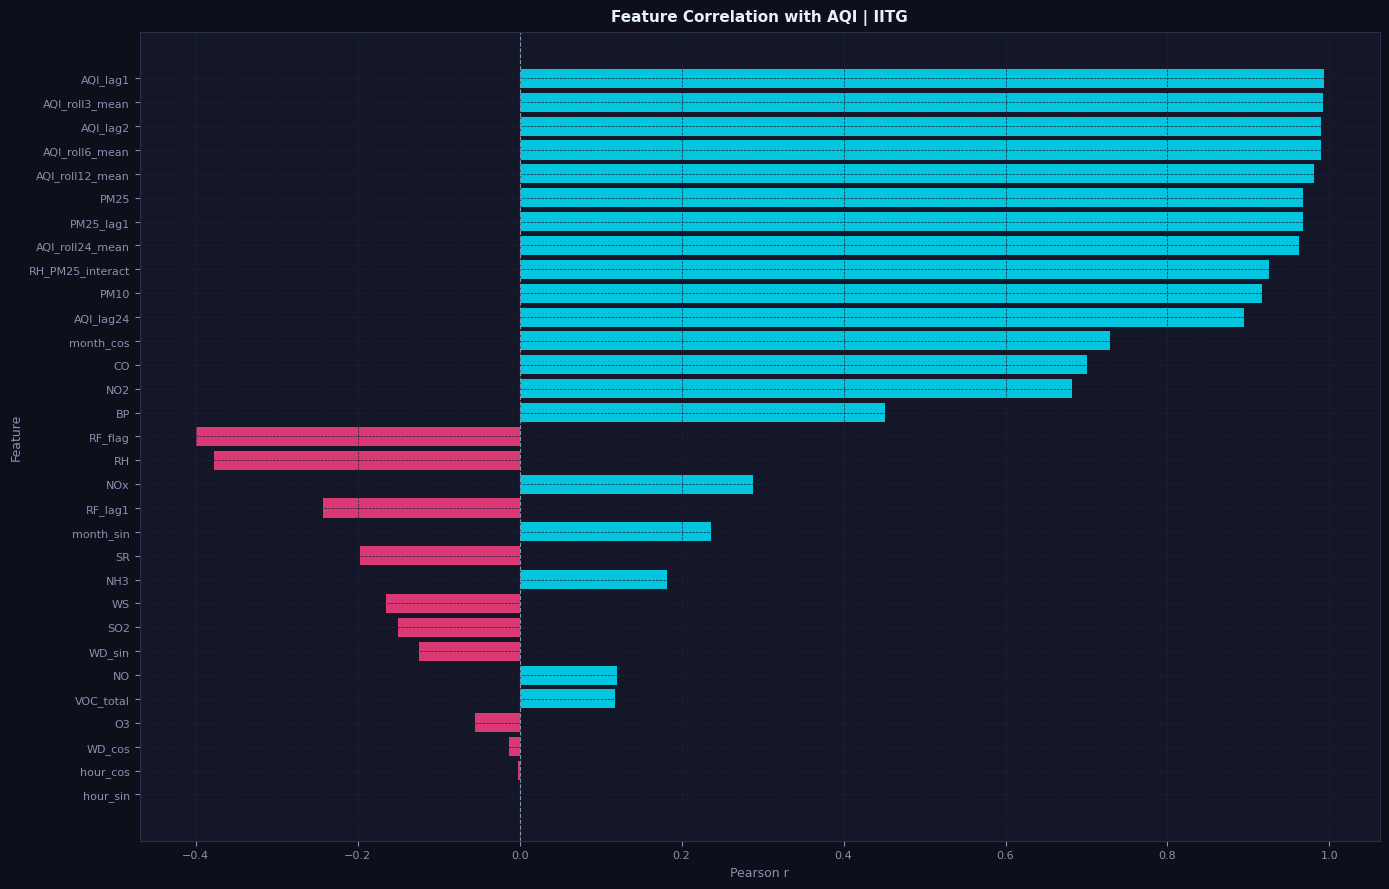

Top 15 features by |correlation|:
AQI_lag1            0.992787
AQI_roll3_mean      0.992388
AQI_lag2            0.989474
AQI_roll6_mean      0.989451
AQI_roll12_mean     0.981424
PM25                0.967216
PM25_lag1           0.967008
AQI_roll24_mean     0.962697
RH_PM25_interact    0.924820
PM10                0.917291
AQI_lag24           0.895084
month_cos           0.728438
CO                  0.700884
NO2                 0.681509
BP                  0.451144


In [7]:
# ── Correlation bar chart with AQI ───────────────────────────────────────────
corr = data.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 9), facecolor=DARK)
colors = [ACC1 if v >= 0 else ACC2 for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
style_ax(ax, f'Feature Correlation with AQI | {STATION_NAME}', 'Pearson r', 'Feature')
plt.tight_layout()
plt.savefig(f'images/feature_correlation_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()

print('Top 15 features by |correlation|:')
print(corr.abs().sort_values(ascending=False).head(15).to_string())


## 5. Robust Scaling (StandardScaler)

Scale all features to zero mean and unit variance.  
A **separate scaler** is kept for the target (AQI) so predictions can be inverse-transformed.

> **Why StandardScaler over MinMax?**  
> The IITG dataset has extreme PM25/PM10 outliers (max PM25 = 399.79 µg/m³, q99 = 341.79).  
> StandardScaler is more robust to these extreme winter-episode spikes.


In [8]:
feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

scaled_features = feature_scaler.fit_transform(data[FEATURES])
scaled_target   = target_scaler.fit_transform(data[[TARGET]])

scaled_data = np.hstack([scaled_features, scaled_target])

print(f'Scaled data shape : {scaled_data.shape}')
print(f'Feature range     : [{scaled_features.min():.4f}, {scaled_features.max():.4f}]')
print(f'Target range      : [{scaled_target.min():.4f}, {scaled_target.max():.4f}]')


Scaled data shape : (28756, 32)
Feature range     : [-6.5971, 19.6489]
Target range      : [-1.1307, 3.1994]


## 6. Create Sliding Window Sequences

LSTM / GRU require 3-D input: **(samples, timesteps, features)**.  

**Look-back = 48 hours** — chosen based on IITG EDA:  
- ACF at lag 24h = **0.895** (very high persistence)
- ACF at lag 48h = **0.837** (still very strong)
- Winter pollution episodes persist for 2–5 days → 48h captures the onset dynamics
- 72h is also valid; 48h is used as a good compute/signal balance.


In [9]:
LOOK_BACK = 48   # EDA: IITG AQI ACF = 0.895 @ 24h, 0.837 @ 48h — high persistence

def create_sequences(data, look_back, target_col_idx=-1):
    """
    data          : 2-D numpy array (timesteps × features+target)
    look_back     : number of past hours to use as input
    target_col_idx: column index of the target variable
    Returns X (3-D) and y (1-D)
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, :target_col_idx])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOK_BACK)

print(f'X shape : {X.shape}  →  (samples, timesteps, features)')
print(f'y shape : {y.shape}  →  (samples,)')


X shape : (28708, 48, 31)  →  (samples, timesteps, features)
y shape : (28708,)  →  (samples,)


## 7. Train / Validation / Test Split

In [10]:
# ── Chronological split — no shuffling ──────────────────────────────────────
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f'Train      : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')
print(f'Input shape for models : {X_train.shape[1:]}')


Train      : 20,095 samples
Validation : 4,306 samples
Test       : 4,307 samples
Input shape for models : (48, 31)


## 8. Build LSTM Model

Architecture:  
`Input → BiLSTM(128) → Dropout(0.25) → LSTM(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

**Adjustments for IITG dataset:**
- Increased units (128/64) matching the expanded feature set (30 features vs 22 for Anand Vihar)
- `BatchNormalization` after second LSTM for training stability with winter outlier spikes
- Dropout(0.25) to mitigate overfitting on the longer, persistent sequences


In [11]:
def build_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiLSTM_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
lstm_model.summary()


Model: "BiLSTM_IITG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,897 (972.25 KB)

 Trainable params: 248,769 (971.75 KB)

 Non-trainable params: 128 (512.00 B)

## 9. Build GRU Model

Architecture:  
`Input → BiGRU(128) → Dropout(0.25) → GRU(64) → BatchNorm → Dropout(0.2) → Dense(32, relu) → Dense(16, relu) → Dense(1)`

GRU uses **reset** and **update** gates vs LSTM's three gates, making it ~30% faster to train.  
Given IITG's strong multi-day persistence (ACF > 0.7 at 168h), both architectures should perform well.


In [12]:
def build_gru(input_shape):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.25),

        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=f'BiGRU_{STATION_NAME.replace(" ", "")}')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

gru_model = build_gru(input_shape=(X_train.shape[1], X_train.shape[2]))
gru_model.summary()


Model: "BiGRU_IITG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 48, 256)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,353 (735.75 KB)

 Trainable params: 188,225 (735.25 KB)

 Non-trainable params: 128 (512.00 B)

## 10. Train Both Models

In [13]:
EPOCHS     = 60
BATCH_SIZE = 64

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'saved_models/best_{model_name}.keras', monitor='val_loss',
                        save_best_only=True, verbose=0)
    ]

print('═' * 50)
print('  Training LSTM …')
print('═' * 50)
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

print('\n' + '═' * 50)
print('  Training GRU …')
print('═' * 50)
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('gru'),
    verbose=1
)

print('\n✅ Both models trained')


══════════════════════════════════════════════════
  Training LSTM …
══════════════════════════════════════════════════
Epoch 1/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 52s 134ms/step - loss: 0.1157 - mae: 0.2372 - val_loss: 0.0873 - val_mae: 0.2371 - learning_rate: 0.0010
Epoch 2/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - loss: 0.0559 - mae: 0.1658 - val_loss: 0.0522 - val_mae: 0.1548 - learning_rate: 0.0010
Epoch 3/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - loss: 0.0455 - mae: 0.1463 - val_loss: 0.0665 - val_mae: 0.1641 - learning_rate: 0.0010
Epoch 4/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - loss: 0.0396 - mae: 0.1338 - val_loss: 0.0739 - val_mae: 0.1701 - learning_rate: 0.0010
Epoch 5/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - loss: 0.0360 - mae: 0.1260 - val_loss: 0.0670 - val_mae: 0.1568 - learning_rate: 0.0010
Epoch 6/60
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0339 - mae: 0.1209
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00050000002374872

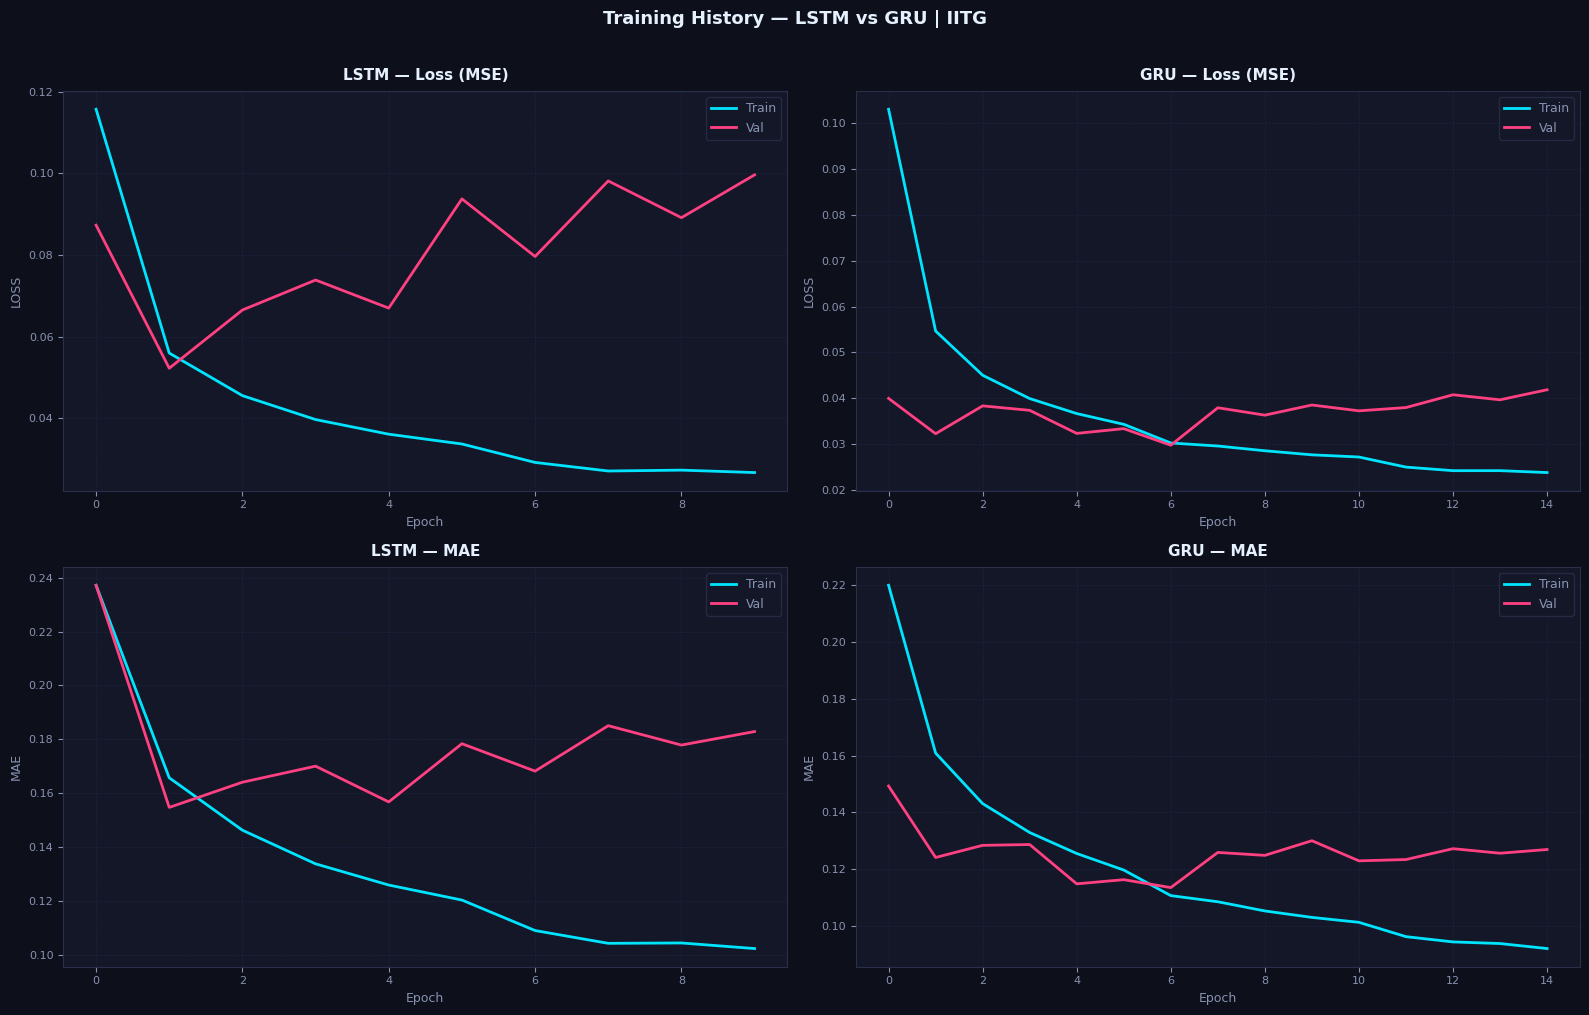

In [14]:
STATION_NAME = 'IITG'

# ── Plot training curves for both models ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DARK)

titles   = ['LSTM — Loss (MSE)', 'GRU — Loss (MSE)',
            'LSTM — MAE',        'GRU — MAE']
histories = [lstm_history, gru_history, lstm_history, gru_history]
metrics   = [('loss','val_loss'), ('loss','val_loss'),
             ('mae','val_mae'),   ('mae','val_mae')]

for ax, hist, (tr_m, va_m), title in zip(axes.flat, histories, metrics, titles):
    ax.plot(hist.history[tr_m], color=ACC1, linewidth=2, label='Train')
    ax.plot(hist.history[va_m], color=ACC2, linewidth=2, label='Val')
    style_ax(ax, title, 'Epoch', tr_m.upper())
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Training History — LSTM vs GRU | {STATION_NAME}', color=WHITE, fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'images/training_history_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 11. Evaluate & Compare on Test Set

In [15]:
def evaluate_model(model, model_path, X_test, y_test, target_scaler, label):
    model.load_weights(model_path)
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred = target_scaler.inverse_transform(y_pred_s).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f'\n  {label}')
    print('  ' + '─' * 38)
    print(f'  MAE   : {mae:.4f}  AQI units')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

    return y_true, y_pred, dict(label=label, MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

print('═' * 45)
print('  TEST SET EVALUATION — IITG Dataset')
print('═' * 45)

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, 'saved_models/best_lstm.keras', X_test, y_test, target_scaler, 'BiLSTM')

y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, 'saved_models/best_gru.keras', X_test, y_test, target_scaler, 'BiGRU')


═════════════════════════════════════════════
  TEST SET EVALUATION — IITG Dataset
═════════════════════════════════════════════

  BiLSTM
  ──────────────────────────────────────
  MAE   : 9.7544  AQI units
  RMSE  : 12.1261
  R²    : 0.9097
  MAPE  : 18.54%

  BiGRU
  ──────────────────────────────────────
  MAE   : 7.6631  AQI units
  RMSE  : 10.6071
  R²    : 0.9309
  MAPE  : 12.97%


In [16]:
# ── Metrics comparison table ──────────────────────────────────────────────────
comp_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('label')
comp_df.index.name = 'Model'

print('\n  COMPARISON TABLE')
print('  ' + '─' * 38)
print(comp_df.round(4).to_string())

winner = comp_df['R2'].idxmax()
print(f'\n  🏆  Best R² → {winner}')



  COMPARISON TABLE
  ──────────────────────────────────────
           MAE     RMSE      R2     MAPE
Model                                   
BiLSTM  9.7544  12.1261  0.9097  18.5405
BiGRU   7.6631  10.6071  0.9309  12.9666

  🏆  Best R² → BiGRU


## 12. Visualise Predictions

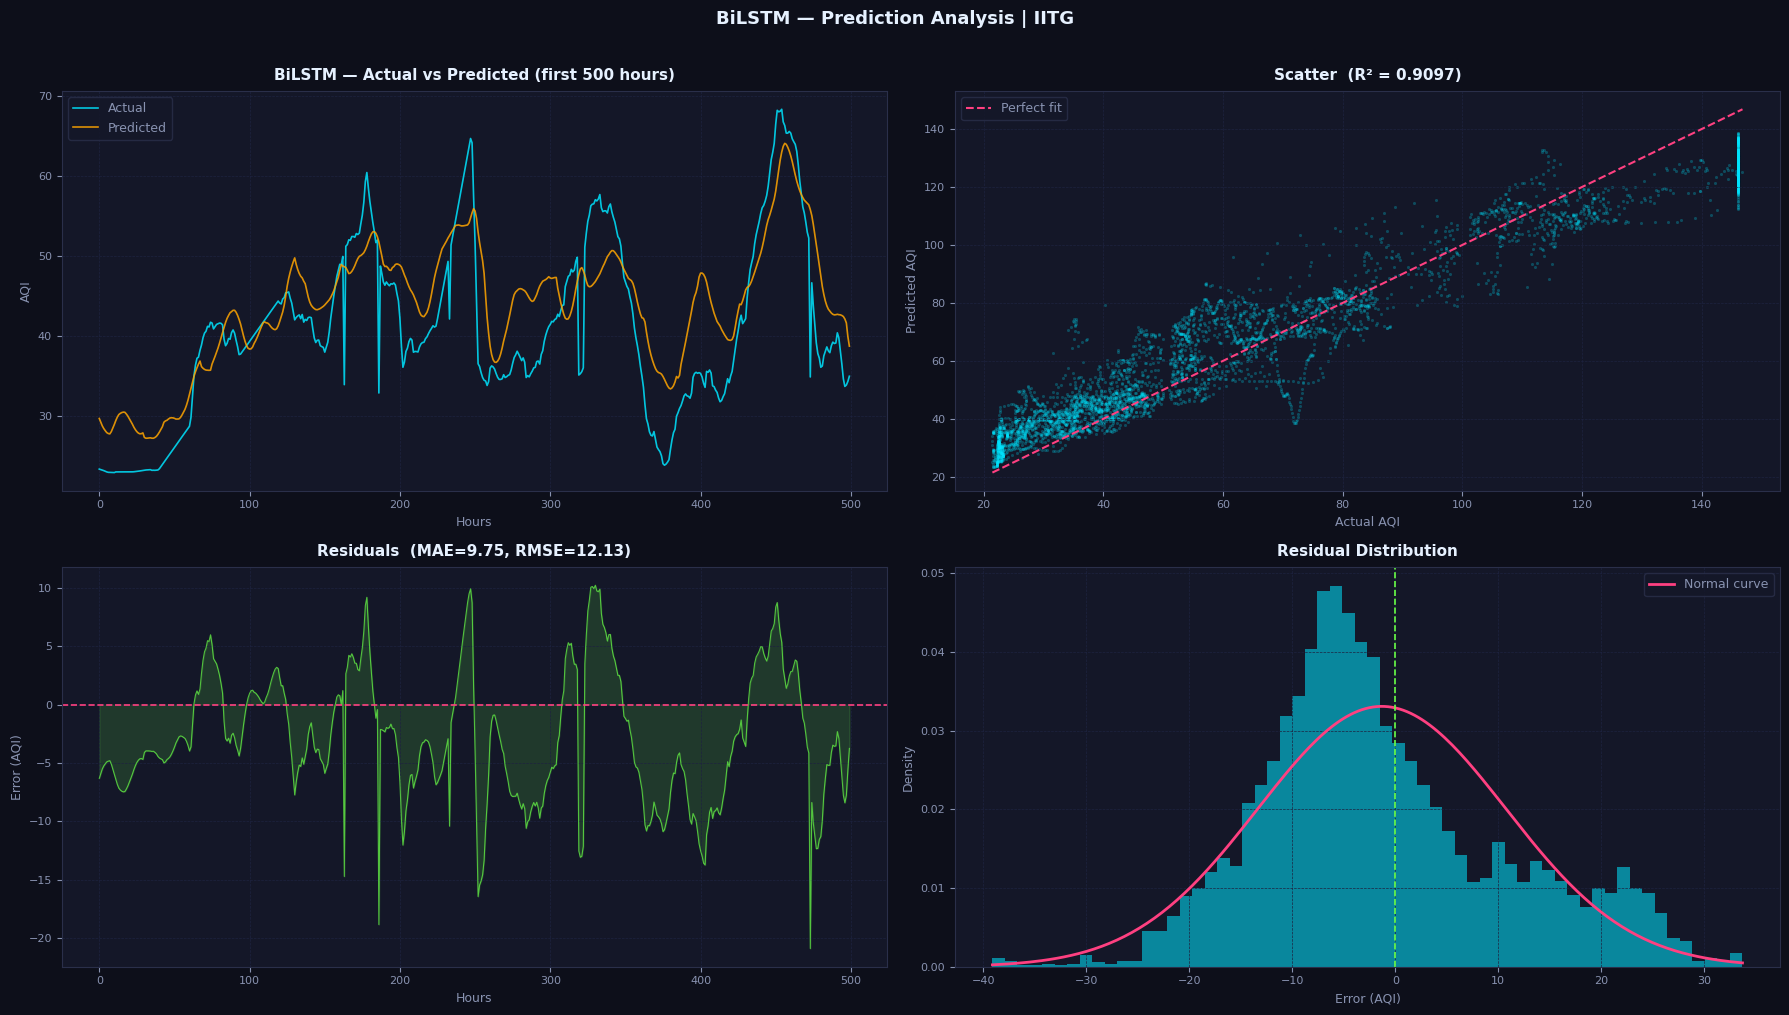

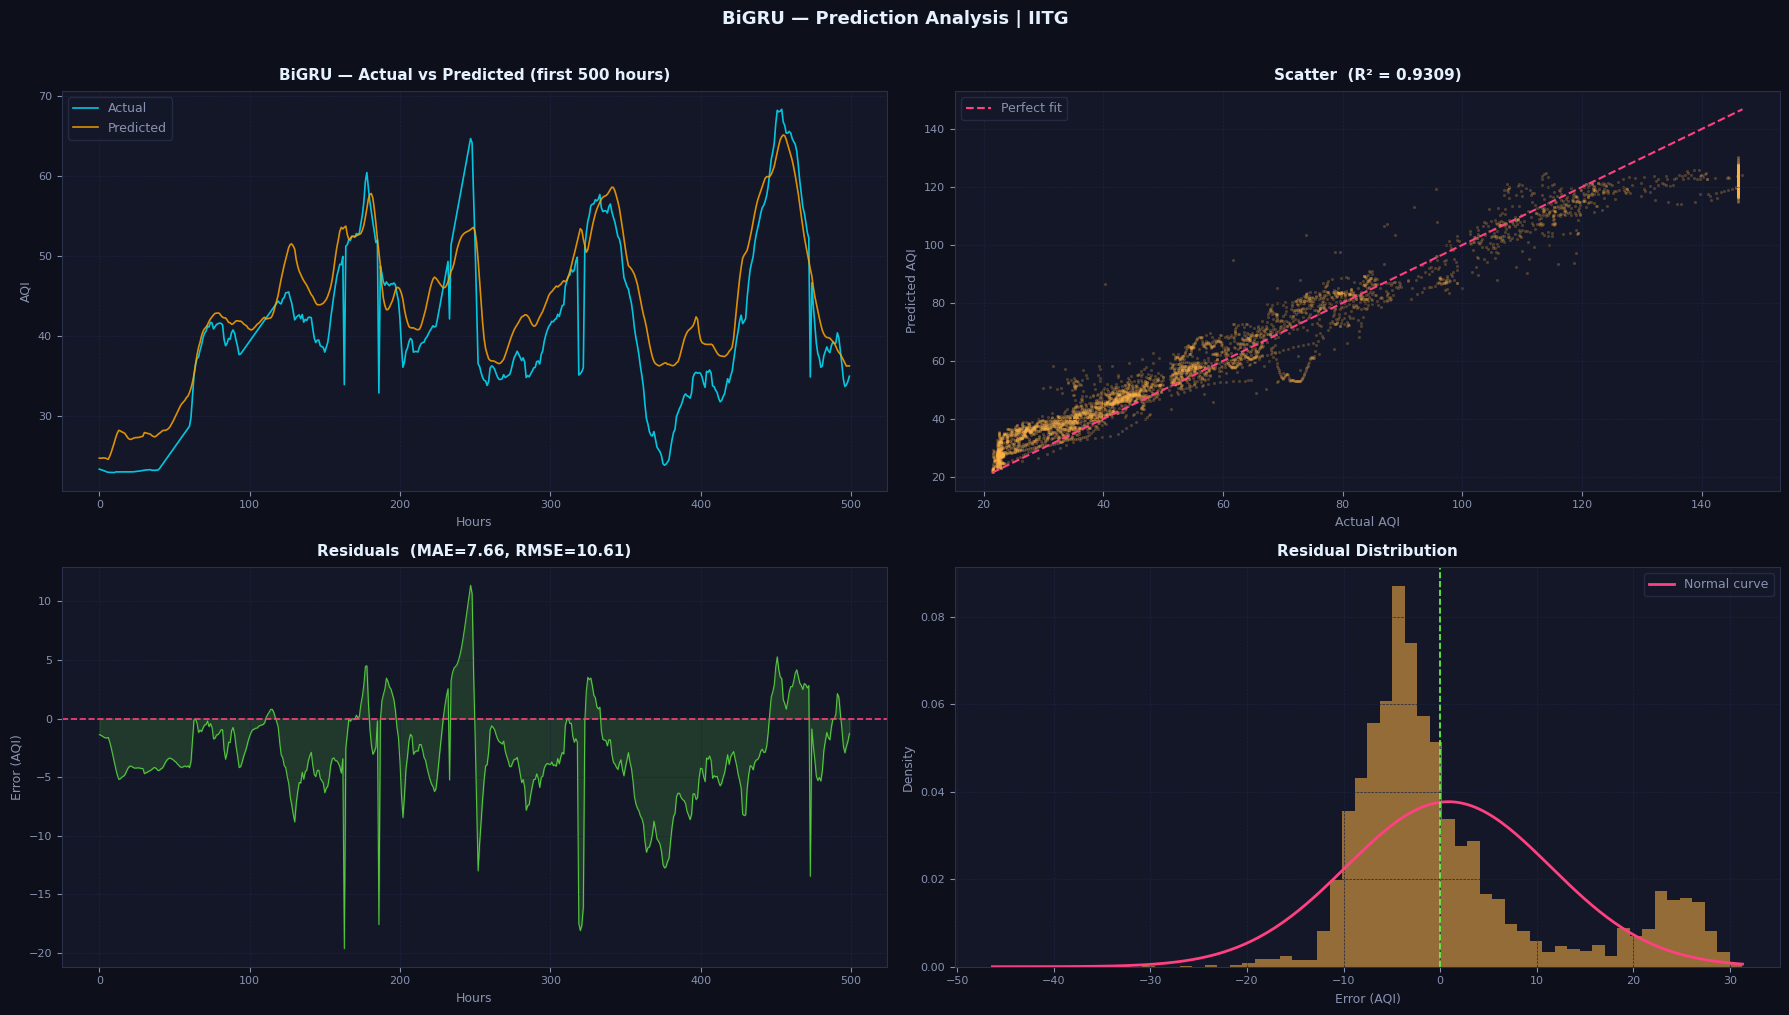

In [17]:
STATION_NAME = 'IITG'

def prediction_dashboard(y_true, y_pred, metrics, label, color, filename):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor=DARK)

    N = min(500, len(y_true))
    r2   = metrics['R2']
    mae  = metrics['MAE']
    rmse = metrics['RMSE']

    # 1. Time series
    ax = axes[0, 0]
    ax.plot(y_true[:N], color=ACC1,  linewidth=1.2, label='Actual',    alpha=0.85)
    ax.plot(y_pred[:N], color='orange', linewidth=1.2, label='Predicted', alpha=0.85)
    style_ax(ax, f'{label} — Actual vs Predicted (first {N} hours)', 'Hours', 'AQI')
    ax.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 2. Scatter
    ax2 = axes[0, 1]
    ax2.scatter(y_true, y_pred, alpha=0.25, s=5, color=color, linewidths=0)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax2.plot(lims, lims, color=ACC2, linewidth=1.5, linestyle='--', label='Perfect fit')
    style_ax(ax2, f'Scatter  (R² = {r2:.4f})', 'Actual AQI', 'Predicted AQI')
    ax2.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    # 3. Residuals
    residuals = y_true - y_pred
    ax3 = axes[1, 0]
    ax3.plot(residuals[:N], color=ACC3, linewidth=0.8, alpha=0.7)
    ax3.axhline(0, color=ACC2, linewidth=1.2, linestyle='--')
    ax3.fill_between(range(N), residuals[:N], alpha=0.15, color=ACC3)
    style_ax(ax3, f'Residuals  (MAE={mae:.2f}, RMSE={rmse:.2f})', 'Hours', 'Error (AQI)')

    # 4. Residual distribution
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=60, color=color, alpha=0.55, edgecolor='none', density=True)
    xr = np.linspace(residuals.min(), residuals.max(), 200)
    ax4.plot(xr, sp_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
             color=ACC2, linewidth=2, label='Normal curve')
    ax4.axvline(0, color=ACC3, linewidth=1.2, linestyle='--')
    style_ax(ax4, 'Residual Distribution', 'Error (AQI)', 'Density')
    ax4.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

    plt.suptitle(f'{label} — Prediction Analysis | {STATION_NAME}', color=WHITE,
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, facecolor=DARK, bbox_inches='tight')
    plt.show()

prediction_dashboard(y_true_lstm, y_pred_lstm, metrics_lstm,
                     'BiLSTM', ACC1, f'images/lstm_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')

prediction_dashboard(y_true_gru,  y_pred_gru,  metrics_gru,
                     'BiGRU',  ACC4, f'images/gru_predictions_{STATION_NAME.lower().replace(" ", "_")}.png')


## 13. Classification Metrics (AQI Category)

CPCB AQI breakpoints:

| AQI Range | Category |
|-----------|----------|
| 0 – 50 | Good |
| 51 – 100 | Satisfactory |
| 101 – 200 | Moderate |
| 201 – 300 | Poor |
| 301 – 400 | Very Poor |
| 401+ | Severe |

Note: IITG dataset has only 2 "Severe" hours — this category may have low precision in classification metrics.


In [18]:
def aqi_to_category(aqi_values):
    cats = []
    for v in aqi_values:
        if   v <= 50:  cats.append('Good')
        elif v <= 100: cats.append('Satisfactory')
        elif v <= 200: cats.append('Moderate')
        elif v <= 300: cats.append('Poor')
        elif v <= 400: cats.append('Very Poor')
        else:          cats.append('Severe')
    return np.array(cats)

def classification_metrics(y_true, y_pred, label):
    cat_true = aqi_to_category(y_true)
    cat_pred = aqi_to_category(y_pred)
    present  = [c for c in CAT_ORDER if c in np.unique(cat_true)]

    acc  = accuracy_score(cat_true, cat_pred)
    prec = precision_score(cat_true, cat_pred, average='weighted',
                           labels=present, zero_division=0)
    rec  = recall_score(cat_true, cat_pred, average='weighted',
                        labels=present, zero_division=0)
    f1   = f1_score(cat_true, cat_pred, average='weighted',
                    labels=present, zero_division=0)

    print(f'\n  {label}')
    print('  ' + '─' * 40)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1        : {f1:.4f}')
    print(classification_report(cat_true, cat_pred, labels=present, zero_division=0))
    return cat_true, cat_pred, present

print('═' * 45)
print('  CLASSIFICATION METRICS — IITG Dataset')
print('═' * 45)
ct_lstm, cp_lstm, present_lstm = classification_metrics(y_true_lstm, y_pred_lstm, 'BiLSTM')
ct_gru,  cp_gru,  present_gru  = classification_metrics(y_true_gru,  y_pred_gru,  'BiGRU')


═════════════════════════════════════════════
  CLASSIFICATION METRICS — IITG Dataset
═════════════════════════════════════════════

  BiLSTM
  ────────────────────────────────────────
  Accuracy  : 0.9041  (90.41%)
  Precision : 0.9105
  Recall    : 0.9041
  F1        : 0.9053
              precision    recall  f1-score   support

        Good       0.96      0.87      0.91      1990
Satisfactory       0.80      0.91      0.85      1332
    Moderate       0.96      0.96      0.96       985

    accuracy                           0.90      4307
   macro avg       0.91      0.92      0.91      4307
weighted avg       0.91      0.90      0.91      4307


  BiGRU
  ────────────────────────────────────────
  Accuracy  : 0.9482  (94.82%)
  Precision : 0.9537
  Recall    : 0.9482
  F1        : 0.9489
              precision    recall  f1-score   support

        Good       1.00      0.91      0.95      1990
Satisfactory       0.87      0.98      0.92      1332
    Moderate       0.99      0.

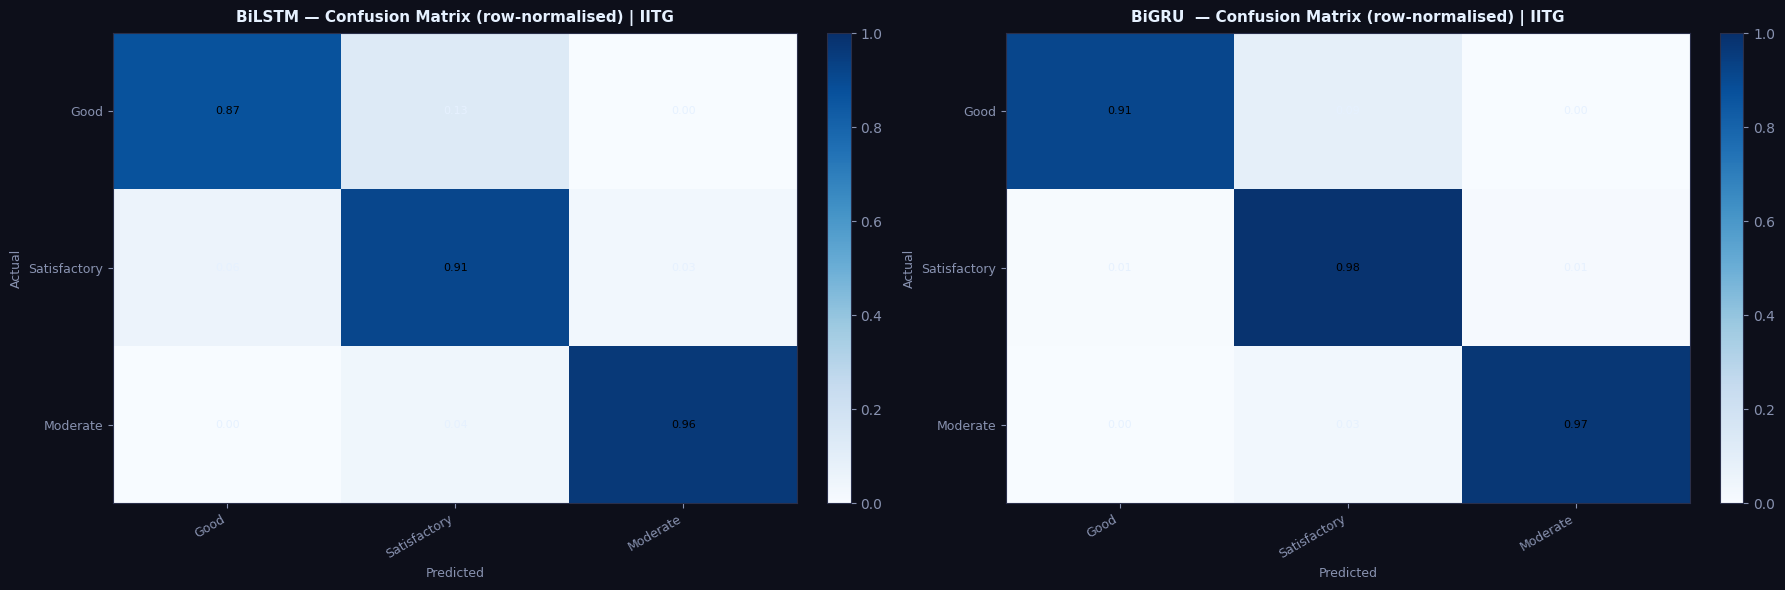

In [19]:
STATION_NAME = 'IITG'

# ── Side-by-side confusion matrices ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=DARK)

for ax, (ct, cp, pres), title in zip(
    axes,
    [(ct_lstm, cp_lstm, present_lstm), (ct_gru, cp_gru, present_gru)],
    [f'BiLSTM — Confusion Matrix (row-normalised) | {STATION_NAME}',
       f'BiGRU  — Confusion Matrix (row-normalised) | {STATION_NAME}']
):
    cm = confusion_matrix(ct, cp, labels=pres)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(pres)))
    ax.set_yticks(range(len(pres)))
    ax.set_xticklabels(pres, rotation=30, ha='right', color=MUTED, fontsize=9)
    ax.set_yticklabels(pres, color=MUTED, fontsize=9)
    ax.set_xlabel('Predicted', color=MUTED, fontsize=9)
    ax.set_ylabel('Actual',    color=MUTED, fontsize=9)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=8)
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2f4a')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors=MUTED)

    thresh = 0.5
    for i in range(len(pres)):
        for j in range(len(pres)):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if cm_norm[i,j] > thresh else WHITE)

plt.tight_layout()
plt.savefig(f'images/confusion_matrices_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 14. Model Comparison Dashboard

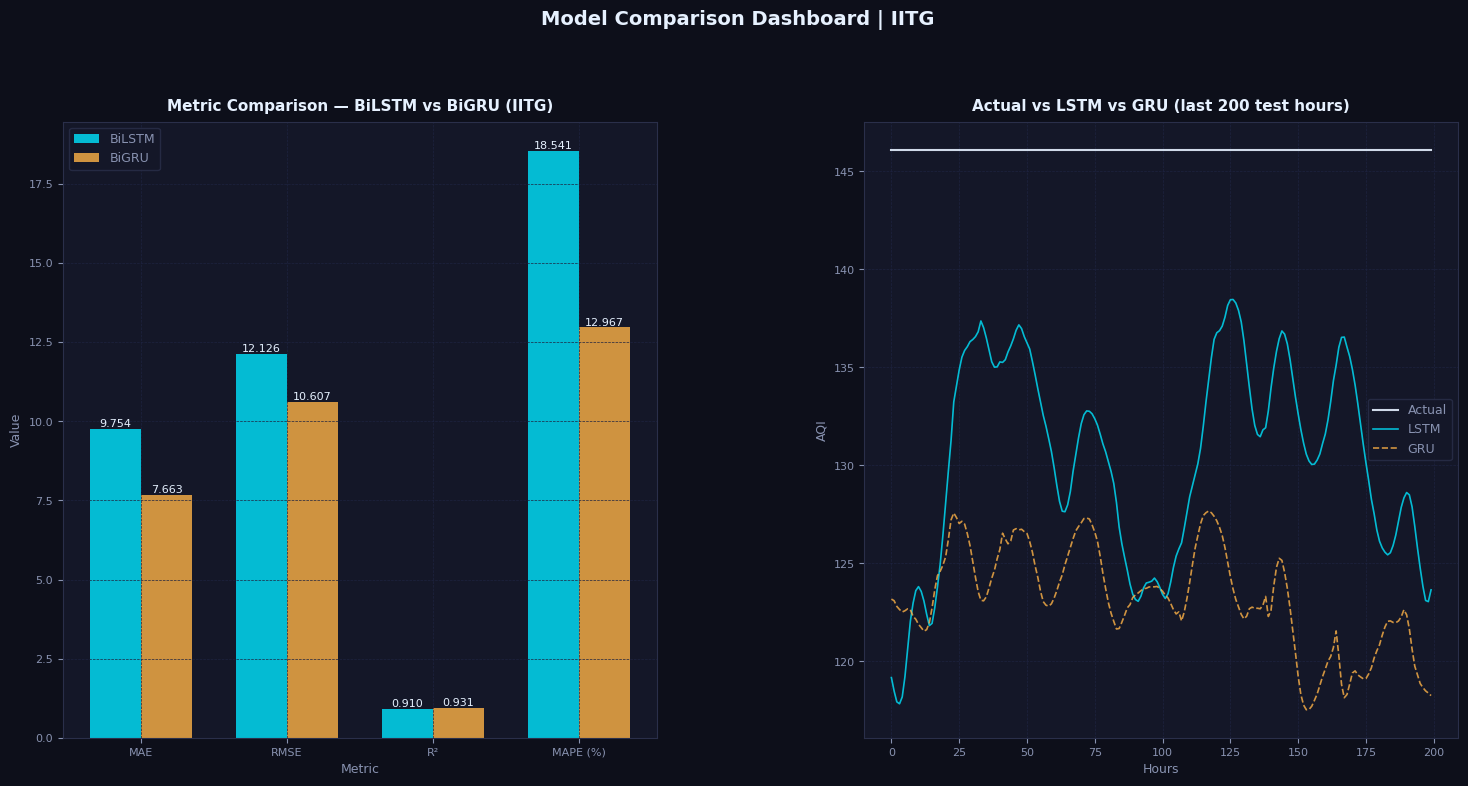

In [20]:
STATION_NAME = 'IITG'

# ── Radar + bar comparison ───────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=DARK)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# -- Bar chart: all metrics --------------------------------------------------
ax_bar = fig.add_subplot(gs[0])

metric_names = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
lstm_vals = [metrics_lstm['MAE'], metrics_lstm['RMSE'],
             metrics_lstm['R2'],  metrics_lstm['MAPE']]
gru_vals  = [metrics_gru['MAE'],  metrics_gru['RMSE'],
             metrics_gru['R2'],   metrics_gru['MAPE']]

x = np.arange(len(metric_names))
w = 0.35
b1 = ax_bar.bar(x - w/2, lstm_vals, w, color=ACC1, alpha=0.8, label='BiLSTM')
b2 = ax_bar.bar(x + w/2, gru_vals,  w, color=ACC4, alpha=0.8, label='BiGRU')

for bar in list(b1) + list(b2):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                color=WHITE, fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names, color=MUTED)
style_ax(ax_bar, f'Metric Comparison — BiLSTM vs BiGRU ({STATION_NAME})', 'Metric', 'Value')
ax_bar.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

# -- Overlay time-series (last 200 hours of test) ----------------------------
ax_ts = fig.add_subplot(gs[1])
N = 200
ax_ts.plot(y_true_lstm[-N:], color=WHITE,  linewidth=1.5, label='Actual',  alpha=0.9, zorder=3)
ax_ts.plot(y_pred_lstm[-N:], color=ACC1,   linewidth=1.2, label='LSTM',    alpha=0.8, zorder=2)
ax_ts.plot(y_pred_gru[-N:],  color=ACC4,   linewidth=1.2, label='GRU',     alpha=0.8, zorder=2,
           linestyle='--')
style_ax(ax_ts, f'Actual vs LSTM vs GRU (last {N} test hours)', 'Hours', 'AQI')
ax_ts.legend(facecolor=CARD, edgecolor='#2a2f4a', labelcolor=MUTED, fontsize=9)

plt.suptitle(f'Model Comparison Dashboard | {STATION_NAME}', color=WHITE, fontsize=14,
             fontweight='bold', y=1.02)
plt.savefig(f'images/model_comparison_{STATION_NAME.lower().replace(" ", "_")}.png', dpi=200, facecolor=DARK, bbox_inches='tight')
plt.show()


## 15. Save Models & Scalers

In [21]:
import joblib

# Save both models
lstm_model.save('saved_models/iitg_lstm_model.keras')
gru_model.save('saved_models/iitg_gru_model.keras')

# Save scalers (required for inference)
joblib.dump(feature_scaler, 'saved_models/iitg_feature_scaler.pkl')
joblib.dump(target_scaler,  'saved_models/iitg_target_scaler.pkl')

# Save feature list (essential for inference alignment)
import json
with open('saved_models/iitg_features.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET, 'look_back': LOOK_BACK}, f, indent=2)

print('✅ LSTM model  →  iitg_lstm_model.keras')
print('✅ GRU  model  →  iitg_gru_model.keras')
print('✅ Scalers     →  iitg_feature_scaler.pkl | iitg_target_scaler.pkl')
print('✅ Feature cfg →  iitg_features.json')


✅ LSTM model  →  iitg_lstm_model.keras
✅ GRU  model  →  iitg_gru_model.keras
✅ Scalers     →  iitg_feature_scaler.pkl | iitg_target_scaler.pkl
✅ Feature cfg →  iitg_features.json


In [22]:
# ── Inference helper ─────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

def predict_next_aqi(recent_df, model_path, feat_scaler, tgt_scaler,
                     features, look_back=48):
    """
    recent_df  : DataFrame with at least `look_back` rows and all feature columns.
                 Must include all engineered features (lags, rolling, WD_sin/cos, etc.)
    Returns    : predicted AQI (float) for the next hour.
    """
    model = load_model(model_path)
    scaled = feat_scaler.transform(recent_df[features].tail(look_back))
    x = scaled.reshape(1, look_back, len(features))
    pred_s = model.predict(x, verbose=0)
    return float(tgt_scaler.inverse_transform(pred_s)[0, 0])

# Quick sanity check using the last window from the test set
sample_df = data.iloc[-(LOOK_BACK + 1):-1]   # 48 rows
for mpath, label in [('saved_models/iitg_lstm_model.keras','LSTM'),
                     ('saved_models/iitg_gru_model.keras', 'GRU')]:
    pred = predict_next_aqi(sample_df, mpath,
                            feature_scaler, target_scaler, FEATURES)
    actual = data[TARGET].iloc[-1]
    print(f'{label:5s}  →  Predicted: {pred:.2f}   Actual: {actual:.2f}')


LSTM   →  Predicted: 123.65   Actual: 146.11
GRU    →  Predicted: 118.25   Actual: 146.11


---
## Summary — IITG AQI LSTM/GRU

| Step | Detail |
|------|--------|
| Dataset | 28,780 hourly records, Sep 2022 – Dec 2025 |
| Features | **30 features** (IITG-specific; no Toluene/AT) |
| Target | AQI (next hour) |
| Scaling | StandardScaler (robust to extreme winter spikes) |
| Look-back window | **48 hours** (ACF = 0.84 at lag-48) |
| LSTM architecture | BiLSTM(128) → LSTM(64) → BN → Dense(32→16→1) |
| GRU  architecture | BiGRU(128) → GRU(64) → BN → Dense(32→16→1) |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE |
| Train/Val/Test | 70% / 15% / 15% |
| Callbacks | EarlyStopping(8), ReduceLROnPlateau(4), ModelCheckpoint |

### Key Differences from Anand Vihar Notebook

| Aspect | Anand Vihar | IITG |
|--------|-------------|------|
| Toluene / AT columns | ✅ Present | ❌ Absent |
| Eth-Benzene / MP-Xylene | ❌ Absent | ✅ Present |
| Wind Direction | ❌ Absent | ✅ Present (WD → WD_sin/cos) |
| Rainfall | ❌ Absent | ✅ Present (RF → RF_flag + RF_lag1) |
| Month encoding | Dropped (diurnal dominant) | **Kept** (seasonal dominant) |
| VOC feature | Toluene_Benzene_ratio | VOC_total (sum of 3 aromatics) |
| lag_24 feature | Dropped | **Kept** (ACF = 0.895 @ 24h) |
| AQI_roll24_mean | Dropped | **Kept** (multi-day episode capture) |
| Total features | 22 | 30 |

### Possible Further Improvements
- Attention mechanism over LSTM/GRU hidden states
- Temporal Fusion Transformer for multi-step forecasting
- Multi-step ahead forecasting (2h, 6h, 12h, 24h)
- Season-specific models (winter vs monsoon) given extreme seasonality
- Ensemble: average LSTM + GRU predictions
- Permutation importance post-training to validate tier assignments empirically
